In [1]:
import torch 
import torch.nn as nn 
from torch.nn import functional as F 
import sys 
sys.path.append('..')
from trainu_net import TrainModel
model = TrainModel.load_from_checkpoint('/home/kathy/projects/project_guo/test/logs/logger_unet/version_1/checkpoints/epoch=14-step=915.ckpt')

In [2]:
from custom_dataset.data_loader import get_dataloader
train_loader, val_loader = get_dataloader()
img, mask = next(iter(val_loader))
img.shape, mask.shape 

(torch.Size([8, 4, 1, 128, 128]), torch.Size([8, 4, 1, 128, 128]))

In [4]:
img , mask = img.to(model.device), mask.to(model.device)

In [5]:
img = img.view(8 * 4, 1, 128, 128)
img = img / 255
pred = model(img)

In [11]:
pred.shape 

torch.Size([32, 5, 128, 128])

In [12]:
pred[:, 0, ...]

tensor([[[ 6.8005,  9.9736, 12.0258,  ..., 12.3047, 11.2335,  6.8546],
         [10.8595, 15.0147, 18.1759,  ..., 18.5582, 16.9787, 11.5079],
         [14.1871, 20.9498, 23.8255,  ..., 24.2849, 22.3670, 15.0658],
         ...,
         [12.1651, 17.3501, 20.0094,  ..., 21.4998, 19.9685, 13.6018],
         [ 9.8392, 14.7927, 16.8447,  ..., 18.0146, 16.1250, 11.0868],
         [ 7.3822, 10.8225, 12.7944,  ..., 13.8183, 12.1094,  7.9536]],

        [[ 6.7999,  9.9727, 12.0248,  ..., 12.3043, 11.2331,  6.8544],
         [10.8585, 15.0134, 18.1744,  ..., 18.5575, 16.9782, 11.5075],
         [14.1858, 20.9480, 23.8235,  ..., 24.2841, 22.3663, 15.0653],
         ...,
         [12.0827, 17.2327, 19.8746,  ..., 21.6084, 20.0697, 13.6719],
         [ 9.7729, 14.6934, 16.7318,  ..., 18.1054, 16.2068, 11.1436],
         [ 7.3328, 10.7500, 12.7092,  ..., 13.8873, 12.1701,  7.9940]],

        [[ 6.7533,  9.9046, 11.9421,  ..., 12.3029, 11.2318,  6.8537],
         [10.7846, 14.9120, 18.0512,  ..., 18

In [13]:
pred[:, 1, ...]

tensor([[[ 1.8994,  4.3394,  4.6480,  ...,  2.5695,  3.0696,  1.6102],
         [ 3.7784,  7.4302,  8.4212,  ...,  5.9909,  6.9807,  3.3587],
         [ 6.6447, 11.2141, 12.8431,  ...,  9.6437, 10.1040,  5.7688],
         ...,
         [ 4.6130,  7.5542,  8.2573,  ...,  5.3792,  7.7749,  3.9847],
         [ 3.0221,  5.4134,  6.4780,  ...,  4.1419,  6.0647,  3.9174],
         [ 1.8315,  3.2673,  3.2482,  ...,  2.3904,  2.7030,  1.6697]],

        [[ 1.8992,  4.3389,  4.6475,  ...,  2.5693,  3.0694,  1.6101],
         [ 3.7780,  7.4294,  8.4204,  ...,  5.9905,  6.9804,  3.3586],
         [ 6.6440, 11.2130, 12.8419,  ...,  9.6432, 10.1036,  5.7685],
         ...,
         [ 4.5813,  7.5024,  8.2008,  ...,  5.4058,  7.8124,  4.0039],
         [ 3.0012,  5.3757,  6.4333,  ...,  4.1620,  6.0950,  3.9373],
         [ 1.8190,  3.2447,  3.2256,  ...,  2.4020,  2.7162,  1.6780]],

        [[ 1.8874,  4.3122,  4.6198,  ...,  2.5685,  3.0687,  1.6097],
         [ 3.7548,  7.3833,  8.3688,  ...,  5

In [7]:
mask = mask.reshape(8 * 4, 128, 128)
ce_loss = nn.CrossEntropyLoss(label_smoothing=0)
ce_loss(pred, mask)

tensor(0.8419, device='cuda:8', grad_fn=<NllLoss2DBackward0>)

In [8]:
plot_pred = pred.argmax(dim = 1)

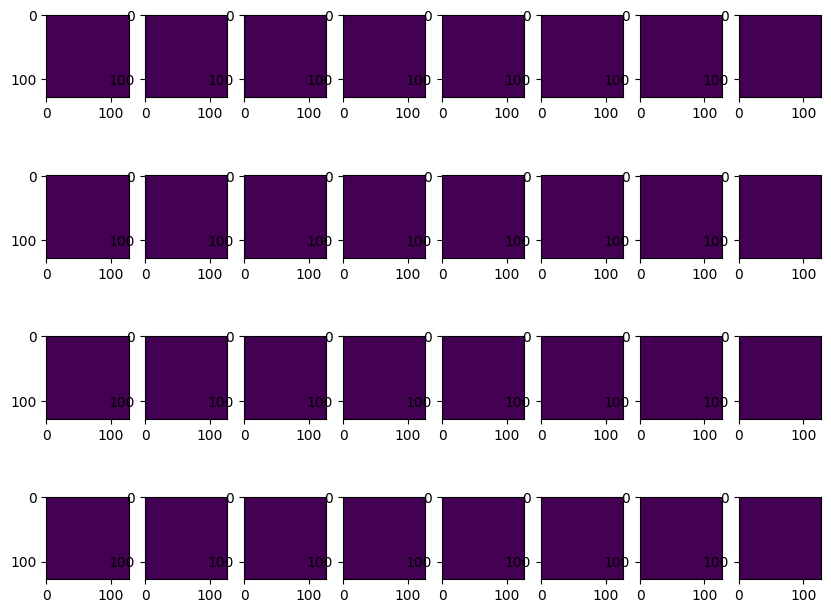

In [9]:
from matplotlib import pyplot as plt 
fig, axes = plt.subplots(4, 8)
fig.set_size_inches(10, 8)
for i in range(32):
    axes.flatten()[i].imshow(plot_pred[i].cpu().detach().numpy())

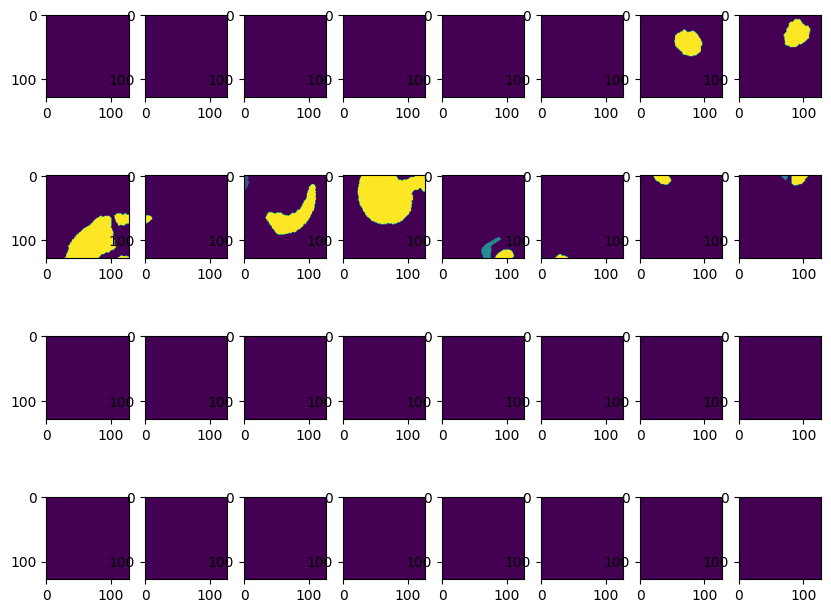

In [10]:
from matplotlib import pyplot as plt 
fig, axes = plt.subplots(4, 8)
fig.set_size_inches(10, 8)
for i in range(32):
    axes.flatten()[i].imshow(mask[i].cpu().detach().numpy())